In [1]:
"""
CARIACO 2D Parameter Scan
=========================
Runs a 2D parameter scan using xso.parscans, computes a normalized
cost metric against observations, and visualizes the fit landscape.

Designed for Jupyter notebook use (copy cells between # %% markers).
"""

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# %%
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from xso.parscans import run_xso_parscan

from parscan_setup import phyto_esd, zoo_esd
from cariaco_data import (
    load_phyto_obs, load_zoo_obs, load_nutrient_obs,
    aggregate_model_state,
)



# %% =========================================================================
# COST FUNCTION
# =============================================================================

def compute_cost_nrmsre(model_vec, obs_vec):
    """
    Normalized Root Mean Square Relative Error.

    cost = sqrt( (1/N) * Σ ((model_i - obs_i) / obs_i)² )

    Properties:
    - Dimensionless (all targets weighted equally regardless of magnitude)
    - Penalizes large individual deviations (no single variable way off)
    - Cost of 0.3 ≈ "on average ~30% relative error"
    - Cost of 1.0 ≈ "on average ~100% off"
    """
    rel_errors = (model_vec - obs_vec) / obs_vec
    return np.sqrt(np.mean(rel_errors ** 2))


def compute_cost_grid(scan_results, phyto_esd, zoo_esd, obs_targets, avg_window,
                      dim1_name, dim2_name):
    """
    Post-process parscan results into a 2D cost grid.

    Parameters
    ----------
    scan_results : xarray.Dataset
        Output from run_xso_parscan with 2 scan dimensions + time + phyto/zoo.
    phyto_esd, zoo_esd : arrays
        Size class centers.
    obs_targets : array of shape (6,)
        [pico, nano, micro, zoo>200, zoo>500, NO3]
    avg_window : int
        Number of final timesteps to average.

    Returns
    -------
    cost_grid : ndarray of shape (n_param1, n_param2)
    model_grid : ndarray of shape (n_param1, n_param2, 6)
    """
    # Identify the two scan dimensions (everything except time, phyto, zoo)
    dim1, dim2 = dim1_name, dim2_name

    # Average over final timesteps
    P_avg = scan_results['Phytoplankton__biomass'].isel(
        time=slice(-avg_window, None)).mean('time')
    Z_avg = scan_results['Zooplankton__biomass'].isel(
        time=slice(-avg_window, None)).mean('time')
    N_avg = scan_results['Nutrient__value'].isel(
        time=slice(-avg_window, None)).mean('time')

    n1 = len(scan_results[dim1])
    n2 = len(scan_results[dim2])

    cost_grid  = np.full((n1, n2), np.nan)
    model_grid = np.full((n1, n2, 6), np.nan)

    for i in range(n1):
        for j in range(n2):
            p_vals = P_avg.isel({dim1: i, dim2: j}).values
            z_vals = Z_avg.isel({dim1: i, dim2: j}).values
            n_val  = N_avg.isel({dim1: i, dim2: j}).values

            # Skip failed runs (NaN)
            if np.any(np.isnan(p_vals)) or np.any(np.isnan(z_vals)) or np.isnan(n_val):
                continue

            mod_p, mod_z, mod_n = aggregate_model_state(
                p_vals, z_vals, n_val, phyto_esd, zoo_esd)

            model_vec = np.array(mod_p + mod_z + mod_n)
            model_grid[i, j, :] = model_vec
            cost_grid[i, j] = compute_cost_nrmsre(model_vec, obs_targets)

    return cost_grid, model_grid, dim1, dim2



In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# --- Parscan settings ---
MODEL_FILE    = 'parscan_setup'   # module name (no .py)
MODEL_NAME    = 'model'
SETUP_NAME    = 'model_setup'
N_PROCESSES   = 20                        # parallel workers
AVG_WINDOW    = 1000                       # days to average at end of IVP

# --- Scan parameter definitions ---
# Each entry: (XSO_param_name, display_label, current_value, scan_range)
# For array parameters, supply a function that generates the array from a scalar.
SCANNABLE_PARAMS = {
    'KsZ':           ('Grazing__KsZ',              'Grazing K_half (mmol N m⁻³)',  3.0,    (0.1, 2.0)),
    'fish_rate':     ('FishGrazing__rate',          'Fish predation rate (d⁻¹)',    0.005,  (0.05, 0.1)),
    'mZ':            ('ZooMortality__rate',         'Zoo mortality rate',           0.1,    (0.01, 0.1)),
    'recycle_frac':  ('PhytoMortality__recycle_frac','Phyto mort. recycle frac',    1.0,    (0.0, 1.0)),
}
# Note: Array parameters (GGE__gge, PhytoMortality__rate) require generating
# full arrays for each scan point. Example for GGE with a scalar multiplier:
#   from npxzxf_parscan_setup import gge as base_gge
#   gge_multipliers = np.linspace(0.5, 1.5, N_POINTS)
#   gge_values = [base_gge * m for m in gge_multipliers]
#   Then pass param_values=gge_values to the scan.

# --- SELECT which two parameters to scan ---
SCAN_KEY_1 = 'KsZ'
SCAN_KEY_2 = 'fish_rate'
N_POINTS_1 = 10        # grid resolution for param 1
N_POINTS_2 = 10        # grid resolution for param 2


# %% =========================================================================
# OBSERVATION TARGETS
# =============================================================================
phyto_obs = load_phyto_obs()
zoo_obs   = load_zoo_obs()
nut_obs   = load_nutrient_obs()

# Target vector: [pico, nano, micro, zoo>200, zoo>500, NO3]
# Using means as the central target for the cost function
OBS_TARGETS = np.array([
    phyto_obs.iloc[:, 0].mean(),   # Pico
    phyto_obs.iloc[:, 1].mean(),   # Nano
    phyto_obs.iloc[:, 2].mean(),   # Micro
    zoo_obs.iloc[:, 0].mean(),     # >200 µm
    zoo_obs.iloc[:, 1].mean(),     # >500 µm
    nut_obs.iloc[:, 0].mean(),     # NO3
])

TARGET_LABELS = [
    'Pico (<2 µm)', 'Nano (2-20 µm)', 'Micro (>20 µm)',
    'Zoo >200 µm', 'Zoo >500 µm', 'NO₃',
]

print("Observation targets (mmol N m⁻³):")
for lab, val in zip(TARGET_LABELS, OBS_TARGETS):
    print(f"  {lab:20s}: {val:.5f}")

Observation targets (mmol N m⁻³):
  Pico (<2 µm)        : 0.17506
  Nano (2-20 µm)      : 0.12162
  Micro (>20 µm)      : 0.15627
  Zoo >200 µm         : 0.05934
  Zoo >500 µm         : 0.03280
  NO₃                 : 2.01581


In [3]:
# %% =========================================================================
# RUN THE 2D SCAN
# =============================================================================

# Build scan ranges
p1_name, p1_label, p1_default, (p1_lo, p1_hi) = SCANNABLE_PARAMS[SCAN_KEY_1]
p2_name, p2_label, p2_default, (p2_lo, p2_hi) = SCANNABLE_PARAMS[SCAN_KEY_2]

param_values_1 = np.linspace(p1_lo, p1_hi, N_POINTS_1)
param_values_2 = np.linspace(p2_lo, p2_hi, N_POINTS_2)

print(f"\n--- 2D Parameter Scan ---")
print(f"  Param 1: {p1_label} ({p1_name})")
print(f"    Range: {p1_lo} – {p1_hi}, {N_POINTS_1} points")
print(f"    Default: {p1_default}")
print(f"  Param 2: {p2_label} ({p2_name})")
print(f"    Range: {p2_lo} – {p2_hi}, {N_POINTS_2} points")
print(f"    Default: {p2_default}")
print(f"  Total runs: {N_POINTS_1 * N_POINTS_2}")

scan_results = run_xso_parscan(
    model_file_name=MODEL_FILE,
    model_name=MODEL_NAME,
    model_setup_name=SETUP_NAME,
    param_name=p1_name,
    param_values=param_values_1,
    param_name2=p2_name,
    param_values2=param_values_2,
    processes=N_PROCESSES,
)

if scan_results is None:
    raise RuntimeError("Parameter scan failed. Check output above for details.")

print("Scan complete. Computing cost grid...")


# %% =========================================================================
# COMPUTE COST GRID
# =============================================================================
cost_grid, model_grid, dim1, dim2 = compute_cost_grid(
    scan_results, phyto_esd, zoo_esd, OBS_TARGETS, AVG_WINDOW,
    dim1_name=p1_name, dim2_name=p2_name)

vals1 = scan_results[dim1].values
vals2 = scan_results[dim2].values

# Find best fit
best_idx = np.unravel_index(np.nanargmin(cost_grid), cost_grid.shape)
best_cost = cost_grid[best_idx]
best_val1 = vals1[best_idx[0]]
best_val2 = vals2[best_idx[1]]
best_model = model_grid[best_idx[0], best_idx[1], :]

print(f"\n--- Best fit ---")
print(f"  {p1_label}: {best_val1:.5f}")
print(f"  {p2_label}: {best_val2:.5f}")
print(f"  Cost (NRMSRE): {best_cost:.4f}")
print(f"\n  Model vs Obs (mmol N m⁻³):")
for lab, mod, obs in zip(TARGET_LABELS, best_model, OBS_TARGETS):
    ratio = mod / obs if obs > 0 else np.nan
    print(f"    {lab:20s}: model={mod:.5f}  obs={obs:.5f}  ratio={ratio:.2f}")


PROGRESS: Completed 10/10 outer points. (Grazing__KsZ = 0.1).

2D Scan complete. Total Time taken: 30.60097 seconds.
Scan complete. Computing cost grid...

--- Best fit ---
  Grazing K_half (mmol N m⁻³): 0.52222
  Fish predation rate (d⁻¹): 0.05000
  Cost (NRMSRE): 0.6291

  Model vs Obs (mmol N m⁻³):
    Pico (<2 µm)        : model=0.20092  obs=0.17506  ratio=1.15
    Nano (2-20 µm)      : model=0.20371  obs=0.12162  ratio=1.67
    Micro (>20 µm)      : model=0.33566  obs=0.15627  ratio=2.15
    Zoo >200 µm         : model=0.08010  obs=0.05934  ratio=1.35
    Zoo >500 µm         : model=0.01102  obs=0.03280  ratio=0.34
    NO₃                 : model=1.76273  obs=2.01581  ratio=0.87


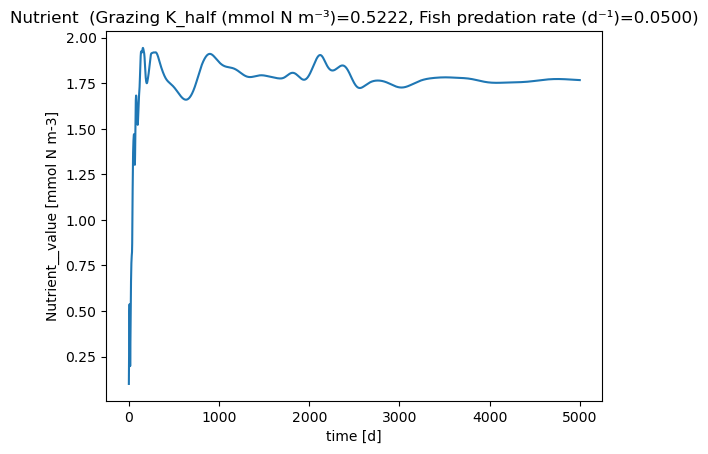

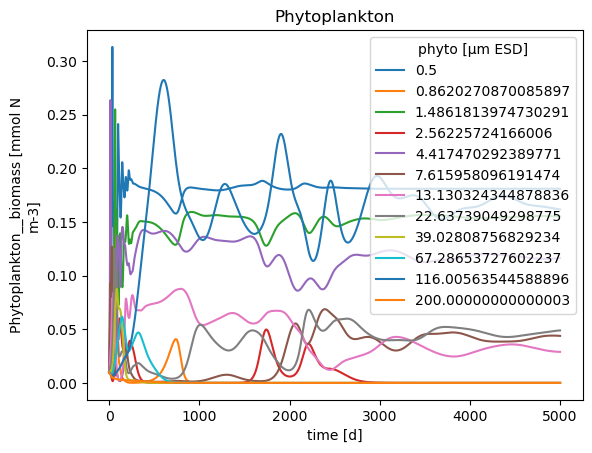

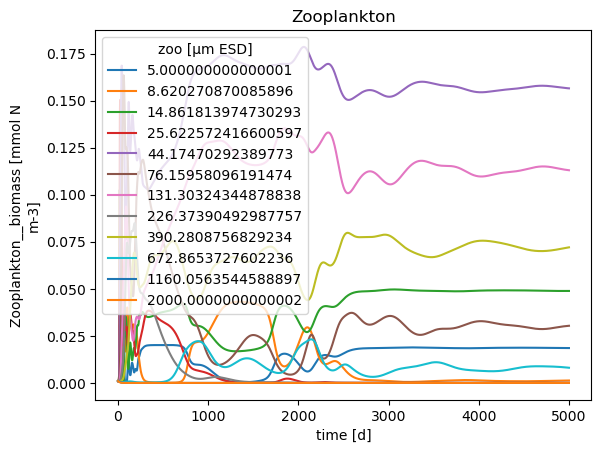

In [4]:
# %% =========================================================================
# DIAGNOSTIC: Best-fit time series
# =============================================================================
best_run = scan_results.sel({dim1: best_val1, dim2: best_val2}, method='nearest')

best_run['Nutrient__value'].plot.line(x='time')
plt.title(f'Nutrient  ({p1_label}={best_val1:.4f}, {p2_label}={best_val2:.4f})')
plt.show()

best_run['Phytoplankton__biomass'].plot.line(x='time')
plt.title('Phytoplankton')
plt.show()

best_run['Zooplankton__biomass'].plot.line(x='time')
plt.title('Zooplankton')
plt.show()

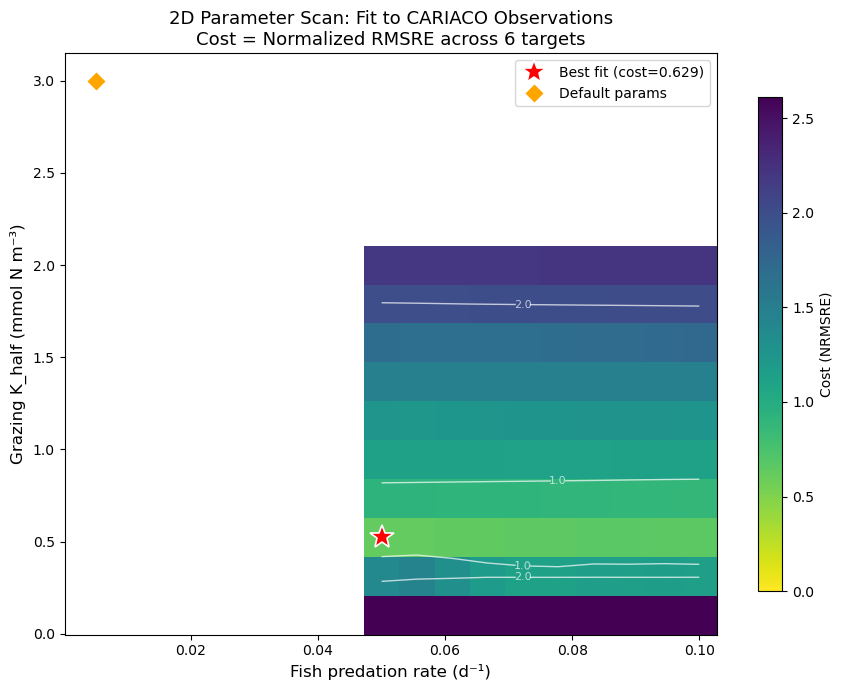

In [5]:

# %% =========================================================================
# PLOT 1: COST HEATMAP
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 7))

# Use log-ish color scale to reveal structure in the low-cost region
vmax = np.nanpercentile(cost_grid, 90)
im = ax.pcolormesh(vals2, vals1, cost_grid,
                   cmap='viridis_r', vmin=0, vmax=vmax, shading='auto')

# Contour lines for good-fit regions
X, Y = np.meshgrid(vals2, vals1)
levels = [0.3, 0.5, 1.0, 2.0]
valid_levels = [l for l in levels if l <= np.nanmax(cost_grid)]
if valid_levels:
    cs = ax.contour(X, Y, cost_grid, levels=valid_levels,
                    colors='white', linewidths=1.0, alpha=0.7)
    ax.clabel(cs, fmt='%.1f', fontsize=8)

# Mark best fit and default
ax.plot(best_val2, best_val1, '*', color='red', markersize=18,
        markeredgecolor='white', markeredgewidth=1.2, label=f'Best fit (cost={best_cost:.3f})')
ax.plot(p2_default, p1_default, 'D', color='orange', markersize=10,
        markeredgecolor='white', markeredgewidth=1.0, label='Default params')

cb = fig.colorbar(im, ax=ax, label='Cost (NRMSRE)', shrink=0.85)
ax.set_xlabel(p2_label, fontsize=12)
ax.set_ylabel(p1_label, fontsize=12)
ax.set_title(f'2D Parameter Scan: Fit to CARIACO Observations\n'
             f'Cost = Normalized RMSRE across {len(TARGET_LABELS)} targets', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()



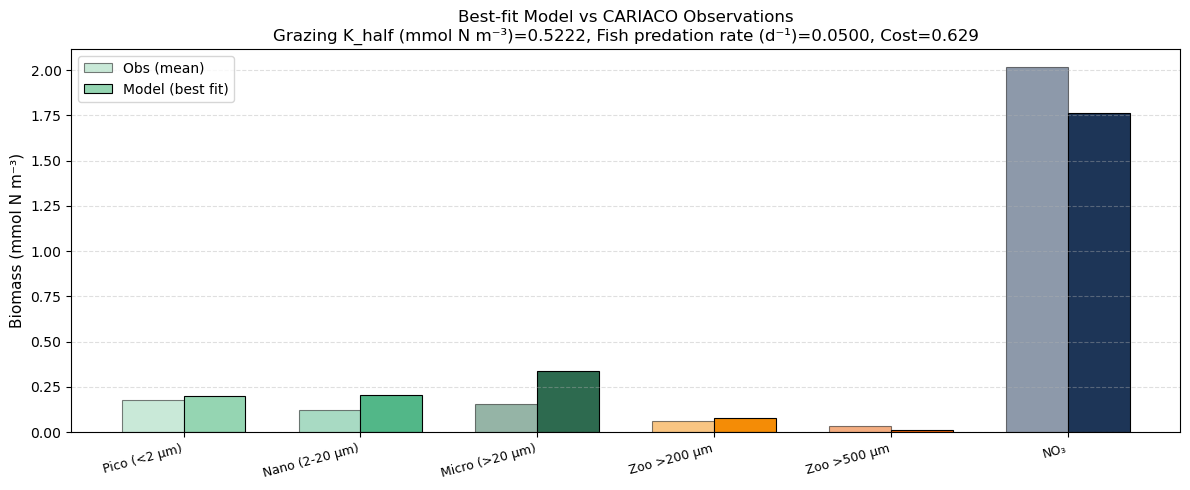

In [6]:

# %% =========================================================================
# PLOT 2: BEST-FIT MODEL vs OBSERVATIONS (bar comparison)
# =============================================================================

# Colors matching the comparison script
colors = ['#95d5b2', '#52b788', '#2d6a4f',   # pico, nano, micro
          '#f48c06', '#e85d04',               # zoo >200, >500
          '#1d3557']                          # NO3

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(TARGET_LABELS))
width = 0.35

bars_obs = ax.bar(x - width/2, OBS_TARGETS, width, color=colors, alpha=0.5,
                  edgecolor='black', linewidth=0.8, label='Obs (mean)')
bars_mod = ax.bar(x + width/2, best_model, width, color=colors,
                  edgecolor='black', linewidth=0.8, label='Model (best fit)')

ax.set_xticks(x)
ax.set_xticklabels(TARGET_LABELS, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Biomass (mmol N m⁻³)', fontsize=11)
ax.set_title(f'Best-fit Model vs CARIACO Observations\n'
             f'{p1_label}={best_val1:.4f}, {p2_label}={best_val2:.4f}, '
             f'Cost={best_cost:.3f}', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
#ax.set_yscale('log')

plt.tight_layout()
plt.show()



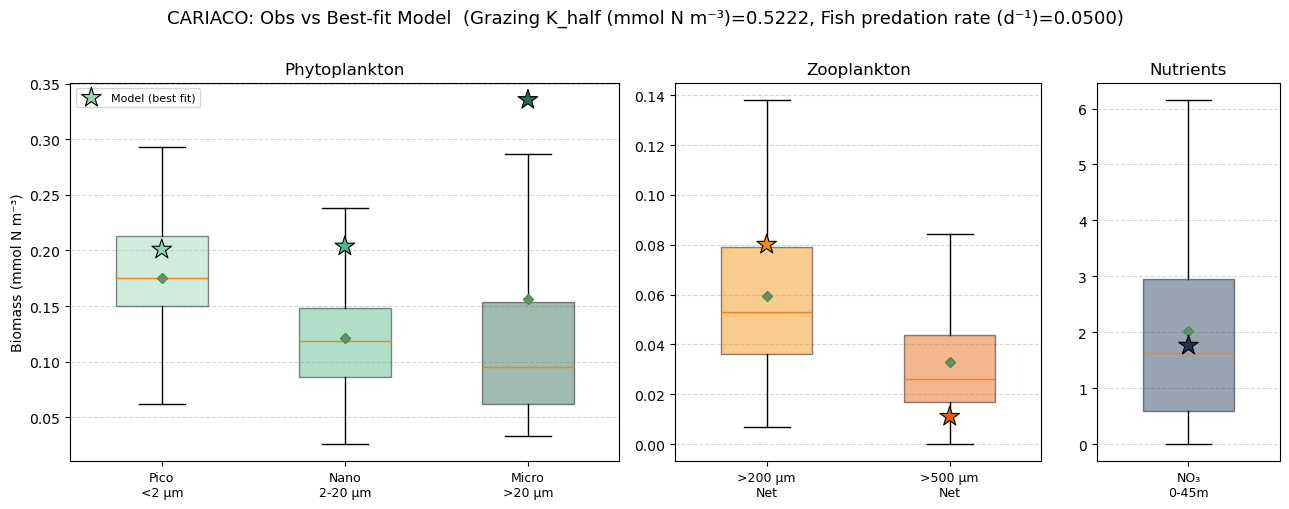

In [7]:

# %% =========================================================================
# PLOT 3: BEST-FIT SIZE SPECTRA vs OBSERVATIONS (boxplots)
# =============================================================================
phyto_obs = load_phyto_obs()
zoo_obs   = load_zoo_obs()
nut_obs   = load_nutrient_obs()

fig, axes = plt.subplots(1, 3, figsize=(13, 5),
                         gridspec_kw={'width_ratios': [3, 2, 1]})

green_shades  = ['#95d5b2', '#52b788', '#2d6a4f']
orange_shades = ['#f48c06', '#e85d04']
blue          = '#1d3557'
star_kw = dict(marker='*', s=220, edgecolor='black', linewidth=0.8, zorder=5)

# Phyto
ax = axes[0]
bp = ax.boxplot([phyto_obs[c] for c in phyto_obs.columns],
                positions=range(3), widths=0.5, patch_artist=True,
                showmeans=True, showfliers=False,
                meanprops=dict(marker='D', markerfacecolor='gray', markersize=5))
for patch, color in zip(bp['boxes'], green_shades):
    patch.set_facecolor(color); patch.set_alpha(0.45)
ax.scatter(range(3), best_model[:3], color=green_shades, **star_kw, label='Model (best fit)')
ax.set_xticks(range(3))
ax.set_xticklabels(['Pico\n<2 µm', 'Nano\n2-20 µm', 'Micro\n>20 µm'], fontsize=9)
ax.set_ylabel('Biomass (mmol N m⁻³)')
ax.set_title('Phytoplankton')
ax.legend(fontsize=8)

# Zoo
ax = axes[1]
bp = ax.boxplot([zoo_obs[c] for c in zoo_obs.columns],
                positions=range(2), widths=0.5, patch_artist=True,
                showmeans=True, showfliers=False,
                meanprops=dict(marker='D', markerfacecolor='gray', markersize=5))
for patch, color in zip(bp['boxes'], orange_shades):
    patch.set_facecolor(color); patch.set_alpha(0.45)
ax.scatter(range(2), best_model[3:5], color=orange_shades, **star_kw)
ax.set_xticks(range(2))
ax.set_xticklabels(['>200 µm\nNet', '>500 µm\nNet'], fontsize=9)
ax.set_title('Zooplankton')

# Nutrients
ax = axes[2]
bp = ax.boxplot([nut_obs.iloc[:, 0]], positions=[0], widths=0.5,
                patch_artist=True, showmeans=True, showfliers=False,
                meanprops=dict(marker='D', markerfacecolor='gray', markersize=5))
bp['boxes'][0].set_facecolor(blue); bp['boxes'][0].set_alpha(0.45)
ax.scatter([0], [best_model[5]], color=blue, **star_kw)
ax.set_xticks([0])
ax.set_xticklabels(['NO₃\n0-45m'], fontsize=9)
ax.set_title('Nutrients')

for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle(f'CARIACO: Obs vs Best-fit Model  '
             f'({p1_label}={best_val1:.4f}, {p2_label}={best_val2:.4f})',
             fontsize=13, y=1.01)
plt.tight_layout()

plt.show()


In [9]:

# %% =========================================================================
# NUMERICAL SUMMARY
# =============================================================================
summary = pd.DataFrame({
    'Component': TARGET_LABELS,
    'Obs_Mean': OBS_TARGETS,
    'Model_BestFit': best_model,
    'Ratio': best_model / OBS_TARGETS,
    'Rel_Error_%': 100 * (best_model - OBS_TARGETS) / OBS_TARGETS,
})

print("\n" + "=" * 75)
print(f" BEST-FIT SUMMARY: {p1_label}={best_val1:.4f}, {p2_label}={best_val2:.4f}")
print(f" Overall cost (NRMSRE): {best_cost:.4f}")
print("=" * 75)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.5f}"))
print("=" * 75)


 BEST-FIT SUMMARY: Grazing K_half (mmol N m⁻³)=1.7857, Fish predation rate (d⁻¹)=0.0622
 Overall cost (NRMSRE): 3.0488
     Component  Obs_Mean  Model_BestFit   Ratio  Rel_Error_%
  Pico (<2 µm)   0.17506        0.58088 3.31824    231.82449
Nano (2-20 µm)   0.12162        0.67150 5.52112    452.11179
Micro (>20 µm)   0.15627        0.98766 6.32039    532.03888
   Zoo >200 µm   0.05934        0.08694 1.46508     46.50789
   Zoo >500 µm   0.03280        0.00000 0.00000   -100.00000
           NO₃   2.01581        0.68763 0.34112    -65.88830
